## Análisis exploratorio de datos: Hospital Beds Managment

La base de datos cuenta con 4 tablas

## Diccionario de datos

Pacients:
- patient_id(String): Identificador. Inicia con PAT
- name(String): Nombre y apellido del paciente
- age (int): Años del paciente
- arrival_date(date): Fecha de ingreso Año/Mes/Día
- departure_date(date): Fecha de salida Año/Mes/Día
- service(String): Tipo de servicio que recibieron 
- satisfaction (int): Score de 0 a 100

Service_Weekly:
Contiene toda la data agragada por servicio hospitalario de un año completo
- week(int); Número por año. De 1 a 52
- month(int): Del 1 al 12
- service(String): Tipo de servicio que ofrece el hospital. Solo tiene 4 posibles valores
- available_beds(int): Camas disponibles para esa semana de 
-  patients_request(int): Número de pacientes que requirieron ser admitidos esa semana
- patients_admitted(int): Número de pacientes admitidos. Depende de las camas disponibles
- patients_refused(int): Número de pacientes rechazados
- patient_safisfaction(int): Promedio de satisfacción de los clientes esa semana. Del o al 100
- staff_morale(int): Promedio de la moral de los empleados durante ese turno/semana. Del 0 al 100.

staff: 
Contiene la información de todo el staff
- staff_id: Indentificador único del staff. Inicia con STF
- staff_name(String): Nombre y apellido
- role(String): Rol dentro del hospital
- service(String): Servicio del hospital asignado

staff_schedule:
Contiene un schudele del staff por cada semana
- week(int): Semana del año. Del 1 al 52
- staff_id(String): Indetificador del staff
- staff_name(String): Nombre del staff
- rol(String)
- service(String)
- present(int): 1 o 0. 1 si estuvo, 0 si faltó

## Objetivos de negocio
Crear un sistema de gestión de información que permita:
- Tener un sistema centralizado de información con los pacientes, su ubicación en el hospital, y el staff
- Registrar pacientes
- Agregar, cambiar y borrar la información de los pacientes y del staff
- Consultar información de pacientes, de staff y de turnos
- Visualizar métricas del hospital

Objetivos del análisis de datos:
- Encontrar patrones entre los indicadores del hospital y la satisfacción de los pacientes
- Identificar la eficiencia del staff y como se comportan es su trabajo en equipo
- Identificar patrones de tiempo 


## Exploración de datos

In [2]:
import pandas as pd
schedule = pd.read_csv(r"C:\Users\poloc\Documents\PruebasGit\Primera prueba\data\raw\staff_schedule.csv")

# True si hay al menos una combinación repetida
print(schedule.duplicated(subset=["week", "staff_id"]).any())

False


In [3]:
#pip install pandas

### Importar las tablas 
Después es importante hacer la conexión a SQlite para poder utilizar los datos como una base de datos. 

In [4]:
import pandas as pd
from pathlib import Path
# Pacientes
patients = pd.read_csv(r"C:\Users\poloc\Documents\PruebasGit\Primera prueba\data\patients.csv")
patients.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\poloc\\Documents\\PruebasGit\\Primera prueba\\data\\patients.csv'

In [ ]:
# staff
staff = pd.read_csv(r"C:\Users\poloc\Documents\PruebasGit\Primera prueba\data\staff.csv")
staff.head()

,staff_id,staff_name,role,service
0,STF-5ca26577,Allison Hill,doctor,emergency
1,STF-02ae59ca,Noah Rhodes,doctor,emergency
2,STF-d8006e7c,Angie Henderson,doctor,emergency
3,STF-212d8b31,Daniel Wagner,doctor,emergency
4,STF-107a58e4,Cristian Santos,doctor,emergency


In [ ]:
# schedule
schedule = pd.read_csv(r"C:\Users\poloc\Documents\PruebasGit\Primera prueba\data\staff_schedule.csv")
schedule.head()

,week,staff_id,staff_name,role,service,present
0,1,STF-b77cdc60,Allison Hill,doctor,emergency,1
1,2,STF-b77cdc60,Allison Hill,doctor,emergency,1
2,3,STF-b77cdc60,Allison Hill,doctor,emergency,0
3,4,STF-b77cdc60,Allison Hill,doctor,emergency,1
4,5,STF-b77cdc60,Allison Hill,doctor,emergency,1


In [ ]:
# Servicios
service = pd.read_csv(r"C:\Users\poloc\Documents\PruebasGit\Primera prueba\data\services_weekly.csv")
service.head()

,week,month,service,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,event
0,1,1,emergency,32,76,32,44,67,70,none
1,1,1,surgery,45,130,45,85,83,78,flu
2,1,1,general_medicine,37,201,37,164,97,43,flu
3,1,1,ICU,22,31,22,9,84,91,flu
4,2,1,emergency,28,169,28,141,75,64,none


### Descripción
A continuación se repite la misma lógica usada para patients para inspeccionar las demás tablas:
- patients: información de pacientes
- staff: información del personal del hospital
- staff_schedule: asistencia del personal por semana
- services_weekly: indicadores semanales por servicio

Se revisa la estructura, los tipos de datos y los resúmenes básicos de cada tabla.

### Pacientes

In [ ]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2   age             1000 non-null   int64 
 3   arrival_date    1000 non-null   object
 4   departure_date  1000 non-null   object
 5   service         1000 non-null   object
 6   satisfaction    1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


Observamos que las tablas staff, staff_schedule y services_weekly también están cargadas correctamente y que sus columnas tienen tipos de datos coherentes para el análisis. La inspección inicial confirma que los datos están listos para trabajar.

In [ ]:
patients.describe()

,age,satisfaction
count,1000.000000,1000.000000
mean,45.337000,79.597000
std,25.999912,11.550325
min,0.000000,60.000000
25%,23.000000,70.000000
50%,46.000000,80.000000
75%,68.000000,89.250000
max,89.000000,99.000000


La información de staff, staff_schedule y services_weekly permite construir una visión general del desempeño operativo del hospital y complementar el análisis de pacientes.

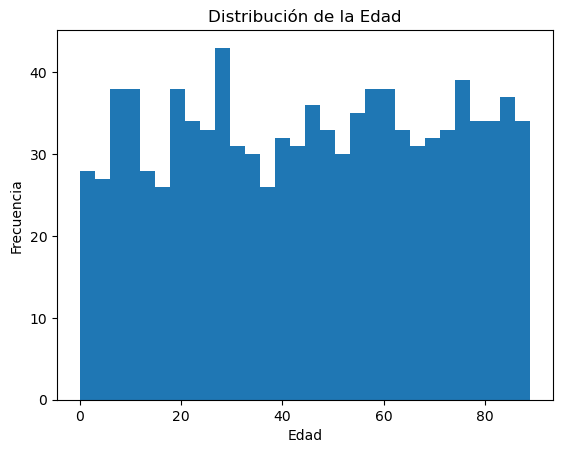

In [ ]:
# Sobre la distribución de la edad
import matplotlib.pyplot as plt
patients['age'].plot(kind='hist', bins=30)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Edad')
plt.show()

Debería ser normal, pero claramente no lo es

Text(0.5, 0, 'Satisfacción')

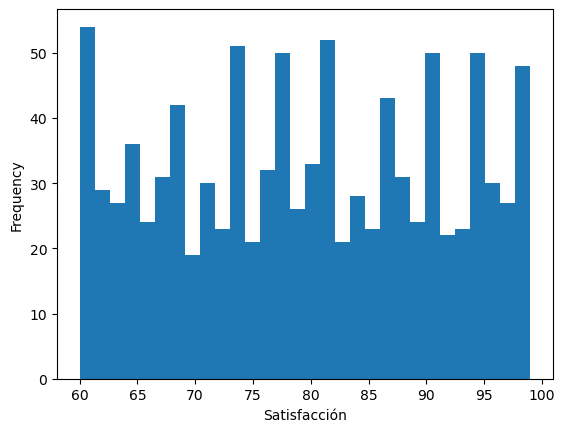

In [ ]:
#Sobre la distrbución de la satisfacción de los pacientes 
patients['satisfaction'].plot(kind='hist', bins=30)
plt.xlabel('Satisfacción') 

Observamos como es la distribución de las variables categóricas

In [ ]:
patients["service"].value_counts().to_frame(name="frecuencia")

,frecuencia
service,
emergency,263
surgery,254
general_medicine,242
ICU,241


No hay una diferencia significativa en la cantidad de pacientes que tomaron cada servicio

-> Observamos que la fecha está como objeto, no como date, lo que puede complicar el análisis

In [ ]:
# Convertir las fechas a date
patients['arrival_date'] = pd.to_datetime(patients['arrival_date'])
patients['departure_date'] = pd.to_datetime(patients['departure_date'])

In [ ]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   patient_id      1000 non-null   object        
 1   name            1000 non-null   object        
 2   age             1000 non-null   int64         
 3   arrival_date    1000 non-null   datetime64[ns]
 4   departure_date  1000 non-null   datetime64[ns]
 5   service         1000 non-null   object        
 6   satisfaction    1000 non-null   int64         
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 54.8+ KB


En esta tabla es interesante observar:
- La relación entre las variables y la satisfacción del paciente
- Entre las variables y el tiempo el tiempo en el que estuvo el paciente en el hospital

Para eso vamos a crear un nuevo dataset para no dañar el que ya tenemos. 

In [ ]:
patients2 = patients.copy()

In [ ]:
patients2["tiempo_estancia"] = (patients2["departure_date"] - patients2["arrival_date"]).dt.days

In [ ]:
patients2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   patient_id       1000 non-null   object        
 1   name             1000 non-null   object        
 2   age              1000 non-null   int64         
 3   arrival_date     1000 non-null   datetime64[ns]
 4   departure_date   1000 non-null   datetime64[ns]
 5   service          1000 non-null   object        
 6   satisfaction     1000 non-null   int64         
 7   tiempo_estancia  1000 non-null   int64         
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 62.6+ KB


Ahora si, revisemos la correlación. 

In [ ]:
patients2[["tiempo_estancia", "satisfaction", "age"]].corr()

,tiempo_estancia,satisfaction,age
tiempo_estancia,1.000000,0.073495,-0.050149
satisfaction,0.073495,1.000000,-0.056229
age,-0.050149,-0.056229,1.000000


Tenemos que existe una muy baja correlación. 

In [ ]:
df = patients.copy()

df["arrival_date"] = pd.to_datetime(df["arrival_date"], format="%Y-%m-%d")
df["departure_date"] = pd.to_datetime(df["departure_date"], format="%Y-%m-%d")
df["arrival_week"] = df["arrival_date"].dt.isocalendar().week.astype(int)
df["departure_week"] = df["departure_date"].dt.isocalendar().week.astype(int)
df = df[["patient_id", "name", "arrival_date", "departure_date", "service", "satisfaction", "arrival_week", "departure_week"]]
df.head()

NameError: name 'patients' is not defined

### Staff

In [ ]:
staff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    110 non-null    object
 1   staff_name  110 non-null    object
 2   role        110 non-null    object
 3   service     110 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB


No tenemos variables numericas. Vamos a observar la frecuencia de las variables categóricas

In [ ]:
staff["service"].value_counts().to_frame(name="frecuencia")

,frecuencia
service,
ICU,32
emergency,29
general_medicine,27
surgery,22


In [ ]:
staff["role"].value_counts().to_frame(name="frecuencia")

,frecuencia
role,
nurse,69
nursing_assistant,23
doctor,18


In [ ]:
staff.describe()


,staff_id,staff_name,role,service
count,110,110,110,110
unique,110,110,3,4
top,STF-5ca26577,Allison Hill,nurse,ICU
freq,1,1,69,32


### Service

In [ ]:
service.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   week                  208 non-null    int64 
 1   month                 208 non-null    int64 
 2   service               208 non-null    object
 3   available_beds        208 non-null    int64 
 4   patients_request      208 non-null    int64 
 5   patients_admitted     208 non-null    int64 
 6   patients_refused      208 non-null    int64 
 7   patient_satisfaction  208 non-null    int64 
 8   staff_morale          208 non-null    int64 
 9   event                 208 non-null    object
dtypes: int64(8), object(2)
memory usage: 16.4+ KB


In [ ]:
# Descripción de staff
staff.info()

# Descripción de staff_schedule
schedule.info()

# Descripción de services_weekly
service.info()

# Resumen estadístico de staff
staff.describe()

# Resumen estadístico de staff_schedule
schedule.describe()

# Resumen estadístico de services_weekly
service.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    110 non-null    object
 1   staff_name  110 non-null    object
 2   role        110 non-null    object
 3   service     110 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   week        6552 non-null   int64 
 1   staff_id    6552 non-null   object
 2   staff_name  6552 non-null   object
 3   role        6552 non-null   object
 4   service     6552 non-null   object
 5   present     6552 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 307.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 10 columns):
 #   Column                Non-Nu

,week,month,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,26.500000,6.923077,30.346154,64.870192,28.129808,36.740385,80.000000,72.567308
std,15.044539,3.634755,15.172929,58.738572,14.676791,55.015763,11.125546,15.457759
min,1.000000,1.000000,8.000000,5.000000,5.000000,0.000000,60.000000,31.000000
25%,13.750000,4.000000,18.000000,23.750000,16.000000,0.000000,70.000000,60.000000
50%,26.500000,7.000000,27.500000,49.000000,26.000000,13.500000,81.000000,73.000000
75%,39.250000,10.000000,40.000000,86.000000,37.000000,52.500000,89.000000,86.000000
max,52.000000,12.000000,74.000000,388.000000,74.000000,363.000000,99.000000,99.000000


Observamos que el modelo es repetitivo, y para crear una base de datos correcta es importante corregir la redundancia. 